## Environment Setup

In [493]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder,PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


## Load Data

In [494]:
df = pd.read_csv("taxi_trip_pricing (1).csv")

## Exploratory Data Analysis (EDA)

In [495]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [496]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [497]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [498]:
df.describe(include="O")

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
count,950,950,950,950
unique,4,2,3,3
top,Afternoon,Weekday,Low,Clear
freq,371,655,397,667


## Explore Null and Duplicated Data

In [499]:
df.isna().mean()*100

,0
Trip_Distance_km,5.0
Time_of_Day,5.0
Day_of_Week,5.0
Passenger_Count,5.0
Traffic_Conditions,5.0
Weather,5.0
Base_Fare,5.0
Per_Km_Rate,5.0
Per_Minute_Rate,5.0
Trip_Duration_Minutes,5.0


In [500]:
df.duplicated().sum()

np.int64(0)

## Data visualization and Univariate analysis


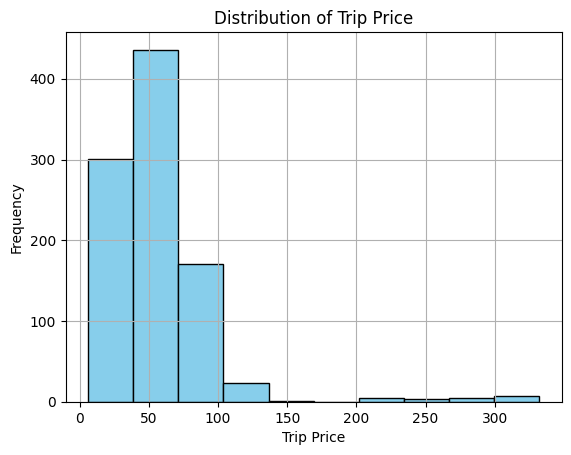

In [501]:
# Distribution of Trip Price
df["Trip_Price"].hist(bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Trip Price")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Price")
plt.show()

* we have right skwed some trips have  high cost resulet skwed

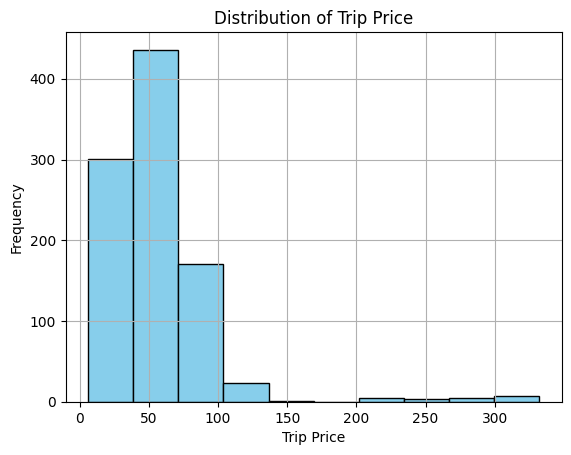

In [502]:
# Distribution of Trip Price
df["Trip_Price"].hist(bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Trip Price")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Price")
plt.show()

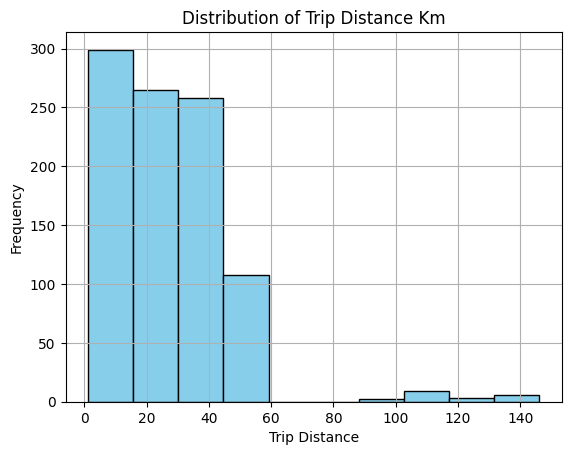

In [503]:
# Distribution of Trip Price
df["Trip_Distance_km"].hist(bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Distance Km")
plt.show()

## Bivariate Analysis

In [504]:
df["Trip_Price"].describe()

,Trip_Price
count,951.000000
mean,56.874773
std,40.469791
min,6.126900
25%,33.742650
50%,50.074500
75%,69.099350
max,332.043689


In [505]:
df["Trip_Price"].quantile([0.25,0.5,0.75,0.95])

,Trip_Price
0.25,33.74265
0.50,50.07450
0.75,69.09935
0.95,102.38090


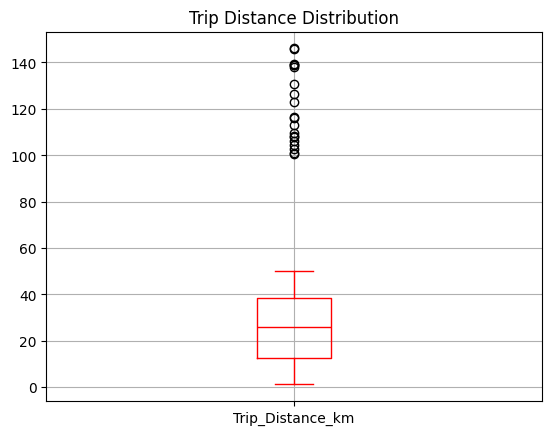

In [506]:
# Trip Price Vs Trip Distance
df['Trip_Distance_km'].plot(kind="box", color='red')

plt.title("Trip Distance Distribution")
plt.grid(True)
plt.show()

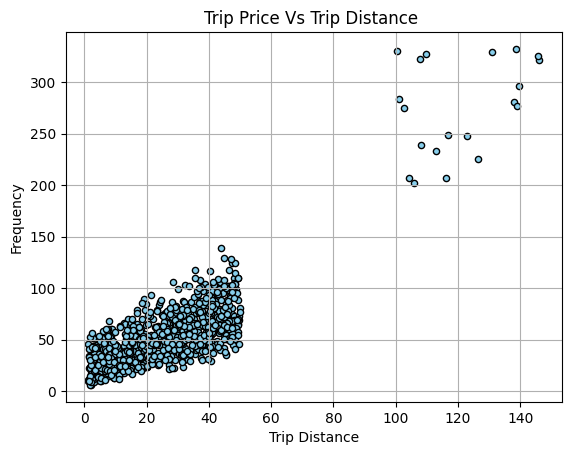

In [507]:
# Trip Price Vs Trip Distance
df.plot(kind="scatter",x="Trip_Distance_km", y="Trip_Price", color='skyblue', edgecolor='black')
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.title("Trip Price Vs Trip Distance ")
plt.grid(True)
plt.show()

* Trip price increaces by distance incressing it's positive linear correlation
* most values of trips grouped under 100 $ about 95% of trips


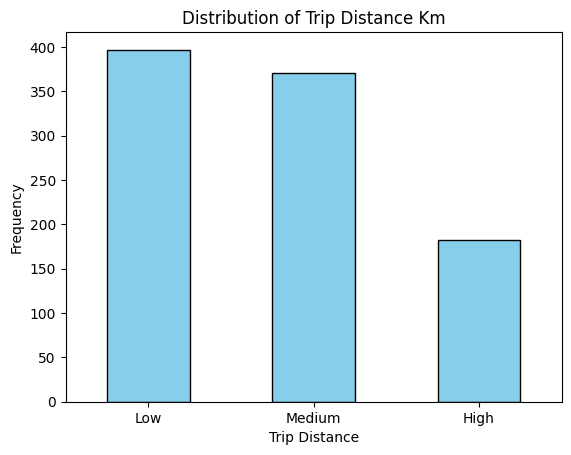

In [508]:
# Average Trip Price Vs Traffic_Conditions
fig = df["Traffic_Conditions"].value_counts()

fig.plot(kind="bar",x="Traffic_Conditions", color='skyblue', edgecolor='black')
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Distance Km")
plt.xticks(rotation=0)
plt.show()

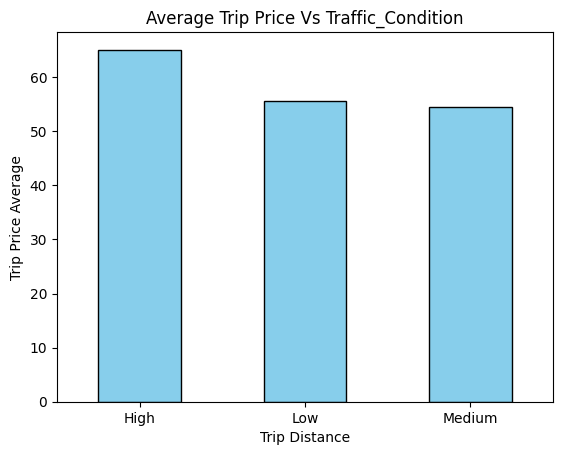

,Trip_Price
Traffic_Conditions,
High,65.059510
Low,55.597238
Medium,54.547422


In [509]:
# Average Trip Price Vs Traffic_Condition
fig = df.groupby("Traffic_Conditions")["Trip_Price"].mean()

fig.plot(kind="bar",x="Traffic_Conditions", y="Trip_Price", color='skyblue', edgecolor='black')
plt.xlabel("Trip Distance")
plt.ylabel("Trip Price Average")
plt.title("Average Trip Price Vs Traffic_Condition")
plt.xticks(rotation=0)
plt.show()
fig

* Average price of trip increase in High Traffic condition But by a small difference
* Traffic condition appears to have a weak direct relationship with Trip Price.

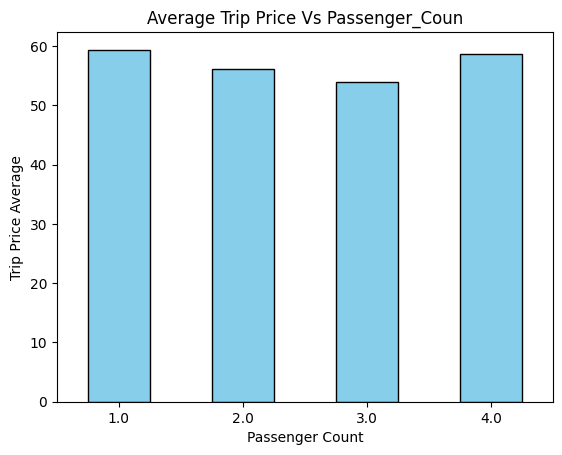

,Trip_Price
Passenger_Count,
1.0,59.411239
2.0,56.165414
3.0,53.887248
4.0,58.613683


In [510]:
# Average Trip Price Vs Passenger_Count
fig = df.groupby("Passenger_Count")["Trip_Price"].mean()

fig.plot(kind="bar",x="Passenger_Count", y="Trip_Price", color='skyblue', edgecolor='black')
plt.xlabel("Passenger Count")
plt.ylabel("Trip Price Average")
plt.title("Average Trip Price Vs Passenger_Coun")
plt.xticks(rotation=0)
plt.show()
fig

* Passenger Count appears to have a weak direct relationship with Trip Price.





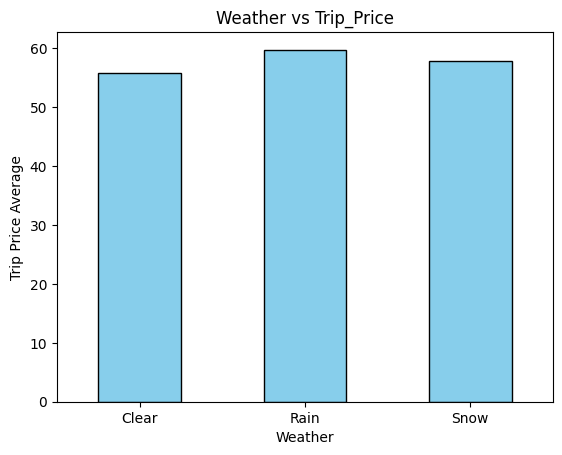

,Trip_Price
Weather,
Clear,55.809128
Rain,59.769260
Snow,57.815842


In [511]:
# Weather vs Trip_Price

fig = df.groupby("Weather")["Trip_Price"].mean()

fig.plot(kind="bar", y="Trip_Price", color='skyblue', edgecolor='black')
plt.xlabel("Weather")
plt.ylabel("Trip Price Average")
plt.title("Weather vs Trip_Price")
plt.xticks(rotation=0)
plt.show()
fig

* Weather appears to have a weak direct relationship with Trip Price.

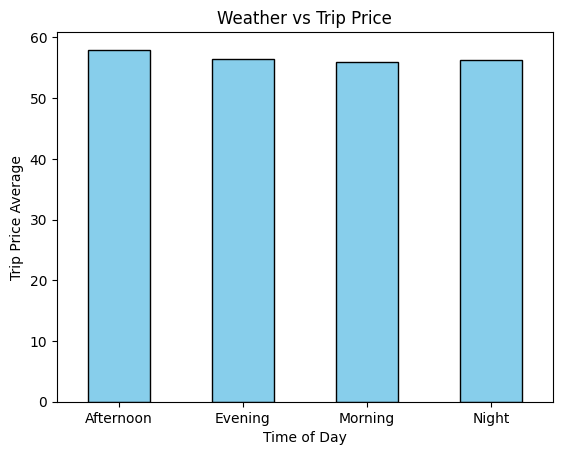

,Trip_Price
Time_of_Day,
Afternoon,57.958716
Evening,56.404504
Morning,55.949429
Night,56.304401


In [512]:
# Time_of_Day vs Trip_Price
fig = df.groupby("Time_of_Day")["Trip_Price"].mean()

fig.plot(kind="bar", y="Trip_Price", color='skyblue', edgecolor='black')
plt.xlabel("Time of Day")
plt.ylabel("Trip Price Average")
plt.title("Weather vs Trip Price")
plt.xticks(rotation=0)
plt.show()
fig

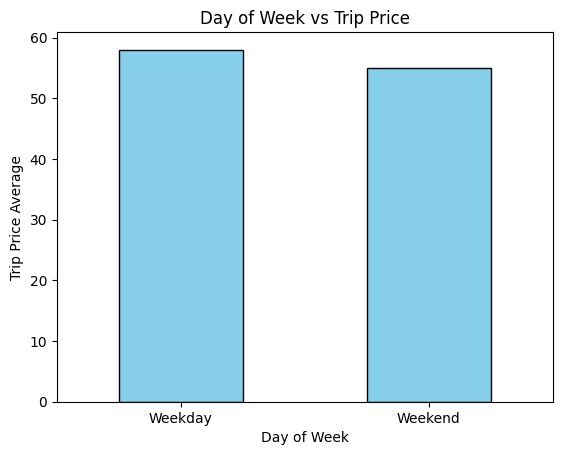

,Trip_Price
Day_of_Week,
Weekday,58.012418
Weekend,55.001961


In [513]:
# Day_of_Week vs Trip_Price
fig = df.groupby("Day_of_Week")["Trip_Price"].mean()

fig.plot(kind="bar", y="Trip_Price", color='skyblue', edgecolor='black')
plt.xlabel("Day of Week")
plt.ylabel("Trip Price Average")
plt.title("Dayof Week vs Trip Price")
plt.xticks(rotation=0)
plt.show()
fig

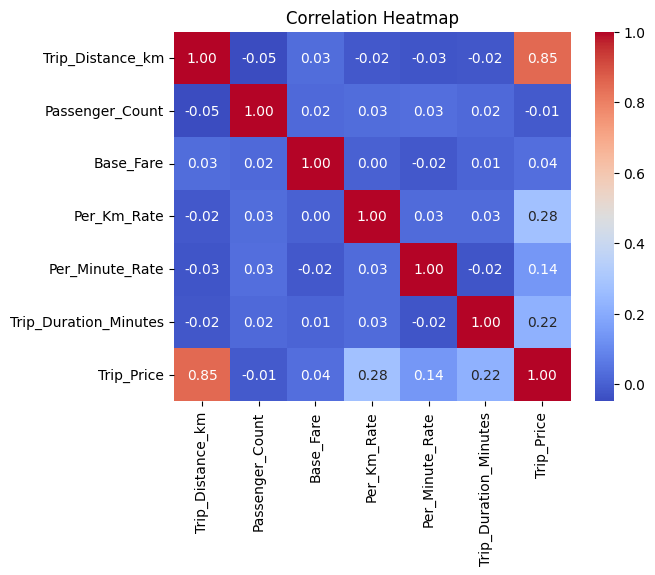

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.048397,0.032218,-0.017041,-0.025902,-0.022102,0.849123
Passenger_Count,-0.048397,1.000000,0.022932,0.030213,0.034068,0.022845,-0.014223
Base_Fare,0.032218,0.022932,1.000000,0.003092,-0.019150,0.012035,0.035533
Per_Km_Rate,-0.017041,0.030213,0.003092,1.000000,0.029241,0.027199,0.275135
Per_Minute_Rate,-0.025902,0.034068,-0.019150,0.029241,1.000000,-0.024230,0.141226
Trip_Duration_Minutes,-0.022102,0.022845,0.012035,0.027199,-0.024230,1.000000,0.221211
Trip_Price,0.849123,-0.014223,0.035533,0.275135,0.141226,0.221211,1.000000


In [514]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
corr_matrix


##Data Preprocessing

In [515]:
df_n = df.copy()
df_n = df_n.dropna(subset=["Trip_Price"]).reset_index(drop=True)



In [516]:
df_n.isna().sum()

,0
Trip_Distance_km,50
Time_of_Day,49
Day_of_Week,46
Passenger_Count,48
Traffic_Conditions,50
Weather,46
Base_Fare,44
Per_Km_Rate,44
Per_Minute_Rate,49
Trip_Duration_Minutes,46


In [517]:
df_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       901 non-null    float64
 1   Time_of_Day            902 non-null    object 
 2   Day_of_Week            905 non-null    object 
 3   Passenger_Count        903 non-null    float64
 4   Traffic_Conditions     901 non-null    object 
 5   Weather                905 non-null    object 
 6   Base_Fare              907 non-null    float64
 7   Per_Km_Rate            907 non-null    float64
 8   Per_Minute_Rate        902 non-null    float64
 9   Trip_Duration_Minutes  905 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 81.9+ KB


In [518]:
features_A = [
    "Trip_Distance_km",
    "Passenger_Count",
    "Weather",
    "Traffic_Conditions",
    "Time_of_Day",
    "Day_of_Week"
]

In [519]:
features_B = [
    "Trip_Distance_km",
    "Passenger_Count",
    "Weather",
    "Traffic_Conditions",
    "Time_of_Day",
    "Day_of_Week",
    "Base_Fare",
    "Per_Km_Rate",
    "Per_Minute_Rate"
]

In [520]:
features_c = [
    "Trip_Distance_km",
    "Passenger_Count",
    "Weather",
    "Traffic_Conditions",
    "Time_of_Day",
    "Day_of_Week",
    "Base_Fare",
    "Per_Km_Rate",
    "Per_Minute_Rate",
    "Trip_Duration_Minutes"
]

In [521]:
# Select Frature and Target
x = df_n[features_c]
y = df_n["Trip_Price"]

In [522]:
# Train , test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)


In [523]:
# Categorical columns
categorical_cols = x_train.select_dtypes(include=['object']).columns.tolist()

# Numerical columns
numerical_cols = x_train.select_dtypes(exclude=['object']).columns.tolist()

x_train[categorical_cols] = x_train[categorical_cols].fillna(x_train[categorical_cols].mode().iloc[0])

x_train[numerical_cols] = x_train[numerical_cols].fillna(x_train[numerical_cols].median())

x_test[categorical_cols] = x_test[categorical_cols].fillna(x_train[categorical_cols].mode().iloc[0])

x_test[numerical_cols] = x_test[numerical_cols].fillna(x_train[numerical_cols].median())
x_train.isna().sum()


,0
Trip_Distance_km,0
Passenger_Count,0
Weather,0
Traffic_Conditions,0
Time_of_Day,0
Day_of_Week,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [524]:
x_test.isna().sum()


,0
Trip_Distance_km,0
Passenger_Count,0
Weather,0
Traffic_Conditions,0
Time_of_Day,0
Day_of_Week,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


## Creat new feature to help model to learn

In [525]:
categorical_cols

['Weather', 'Traffic_Conditions', 'Time_of_Day', 'Day_of_Week']

In [526]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

x_train_cat = encoder.fit_transform(x_train[categorical_cols])

x_test_cat = encoder.transform(x_test[categorical_cols])

In [527]:
print(x_train_cat.shape)
print(x_test_cat.shape)

(808, 12)
(143, 12)


In [528]:
# Convert encoded arrays to DataFrames

x_train_cat = pd.DataFrame(
    x_train_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=x_train.index
)

x_test_cat = pd.DataFrame(
    x_test_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=x_test.index
)

In [529]:
x_train_final = pd.concat(
    [x_train[numerical_cols], x_train_cat],
    axis=1
)

x_test_final = pd.concat(
    [x_test[numerical_cols], x_test_cat],
    axis=1
)

In [530]:
print(x_train_cat.shape)
print(x_test_cat.shape)
x_train_final

(808, 12)
(143, 12)


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Weather_Clear,Weather_Rain,Weather_Snow,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend
595,19.15,2.0,2.01,1.30,0.15,80.61,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
731,25.63,1.0,3.05,0.98,0.24,60.94,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
594,11.26,3.0,2.34,0.68,0.29,58.80,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
137,14.96,1.0,3.79,0.90,0.17,66.66,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
319,24.20,1.0,2.43,0.75,0.28,103.17,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,46.56,3.0,4.46,0.87,0.46,119.21,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
270,2.83,1.0,3.99,0.96,0.19,11.65,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
860,21.65,3.0,2.18,1.05,0.29,24.22,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
435,32.81,2.0,4.84,1.21,0.23,64.74,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [531]:
scaler = StandardScaler()
x_train_final =scaler.fit_transform(x_train_final[numerical_cols])
x_test_final = scaler.transform(x_test_final[numerical_cols])

In [532]:
# linear regression
linear_model = LinearRegression()
linear_model.fit(x_train_final, y_train)
y_pred = linear_model.predict(x_test_final)


mae_linear = mean_absolute_error(y_test, y_pred)
mse_linear = mean_squared_error(y_test, y_pred)
rmse_linear = np.sqrt(mse_linear)
r2_linear= r2_score(y_test, y_pred)
print(f"Linear Regression - MAE: {mae_linear:.2f}, MSE: {mse_linear:.2f}, RMSE: {rmse_linear:.2f}, R2: {r2_linear:.2f}")

Linear Regression - MAE: 10.42, MSE: 352.77, RMSE: 18.78, R2: 0.88


In [533]:
# linear regression with polynomial features
poly_features = PolynomialFeatures(degree=2)
x_train_poly = poly_features.fit_transform(x_train_final)
x_test_poly = poly_features.transform(x_test_final)
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)
y_pred_poly = poly_model.predict(x_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred)
print(f"Polinomial Regression (Degree = 3) - MAE: {mae_poly:.2f}, MSE: {mse_poly:.2f}, RMSE: {rmse_poly:.2f}, R2: {r2_poly:.2f}")

Polinomial Regression (Degree = 3) - MAE: 6.48, MSE: 250.36, RMSE: 15.82, R2: 0.88


In [534]:
# lasso regressor
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train_final, y_train)
y_pred_lasso = lasso_model.predict(x_test_final)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression  - MAE: {mae_lasso:.2f}, MSE: {mse_lasso:.2f}, RMSE: {rmse_lasso:.2f}, R2: {r2_lasso:.2f}")

Lasso Regression  - MAE: 10.38, MSE: 354.80, RMSE: 18.84, R2: 0.88


In [535]:
# Ridge model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train_final, y_train)
y_pred_ridge = ridge_model.predict(x_test_final)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression  - MAE: {mae_ridge:.2f}, MSE: {mse_ridge:.2f}, RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.2f}")

Ridge Regression  - MAE: 10.42, MSE: 352.85, RMSE: 18.78, R2: 0.88


In [536]:
#robust model
huber_model = HuberRegressor()
huber_model.fit(x_train_final, y_train)
y_pred_huber = huber_model.predict(x_test_final)

mae_huber = mean_absolute_error(y_test, y_pred_huber)
mse_huber = mean_squared_error(y_test, y_pred_huber)
rmse_huber = np.sqrt(mse_huber)
r2_huber = r2_score(y_test, y_pred_huber)
print(f"Huber Regression  - MAE: {mae_huber:.2f}, MSE: {mse_huber:.2f}, RMSE: {rmse_huber:.2f}, R2: {r2_huber:.2f}")

Huber Regression  - MAE: 10.19, MSE: 558.57, RMSE: 23.63, R2: 0.81


In [537]:
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": PolynomialFeatures(degree=3),
    "Lasso Regression": Lasso(alpha=0.1),
    "Ridge Regression": Ridge(alpha=1.0),

}

results_train = {}
results_test = {}

for name, model in models.items():
    if name == "Polynomial Regression":
        poly_features = PolynomialFeatures(degree=2)
        X_train_poly = poly_features.fit_transform(x_train_final)
        X_test_poly = poly_features.transform(x_test_final)
        poly_model = LinearRegression()
        poly_model.fit(x_train_poly, y_train)
        y_pred_train = poly_model.predict(X_train_poly)
        y_pred_test = poly_model.predict(X_test_poly)
    else:
        model.fit(x_train_final, y_train)
        y_pred_train = model.predict(x_train_final)
        y_pred_test = model.predict(x_test_final)

    results_train[name] = {
        "MAE": mean_absolute_error(y_train, y_pred_train),
        "MSE": mean_squared_error(y_train, y_pred_train),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2": r2_score(y_train, y_pred_train)
    }

    results_test[name] = {
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "MSE": mean_squared_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2": r2_score(y_test, y_pred_test)
    }


In [538]:
print(f"{'Model':<35} {'Train MAE':<10} {'Test MAE':<10} {'Train MSE':<15} {'Test MSE':<15} {'Train R2':<10} {'Test R2':<10}")
print("=" * 100)

for name in results_train.keys():
    train_metrics = results_train[name]
    test_metrics = results_test[name]

    print(f"{name:<35} {train_metrics['MAE']:<10.2f} {test_metrics['MAE']:<10.2f} "
          f"{train_metrics['MSE']:<15.2f} {test_metrics['MSE']:<15.2f} "
          f"{train_metrics['R2']:<10.2f} {test_metrics['R2']:<10.2f}")


Model                               Train MAE  Test MAE   Train MSE       Test MSE        Train R2   Test R2   
Linear Regression                   9.16       10.42      203.02          352.77          0.85       0.88      
Polynomial Regression               4.82       6.48       81.24           250.36          0.94       0.91      
Lasso Regression                    9.13       10.38      203.08          354.80          0.85       0.88      
Ridge Regression                    9.14       10.41      203.03          353.57          0.85       0.88      


# Conclusion

The objective of this project was to predict taxi trip prices using machine learning regression models. The project involved data cleaning, exploratory data analysis (EDA), feature selection, preprocessing, model training, and performance evaluation.

During the EDA phase, I found that Trip Price has a right-skewed distribution, with most trips costing less than $100. Trip Distance showed the strongest correlation with Trip Price, while variables such as Passenger Count, Weather, Traffic Conditions, Time of Day, and Day of Week had weaker direct relationships.

To better understand the impact of feature selection on model performance, I conducted three different experiments:

### Model A: Pre-Trip Prediction Features

The first model used only the information that would realistically be available before the trip starts:

* Trip Distance
* Passenger Count
* Weather
* Traffic Conditions
* Time of Day
* Day of Week

This model represents a real-world fare estimation system where the final trip details are not yet known. The model achieved reasonable performance and demonstrated that distance is the most important factor in predicting trip prices.

### Model B: Adding Pricing Features

In the second experiment, I added:

* Base Fare
* Per Km Rate
* Per Minute Rate

These variables contain additional pricing information and significantly improved model performance. This experiment showed that providing the model with pricing-related features allows it to better estimate the final fare.

### Model C: Adding Trip Duration

In the final experiment, I added:

* Trip Duration Minutes

This model achieved the best performance, with Polynomial Regression reaching approximately:

* Test R² = 0.91
* Test MAE = 6.48

The improvement confirmed that trip duration is an important factor in determining the final fare.

Among all tested models, Polynomial Regression consistently produced the best results, indicating that the relationship between trip characteristics and trip price is not purely linear.

This project highlighted several important machine learning concepts, including handling missing values, encoding categorical variables, feature scaling, feature selection, model comparison, and the importance of avoiding data leakage. It also demonstrated that improving feature quality often has a greater impact on performance than simply switching to more complex algorithms.

Overall, this project provided valuable hands-on experience in building regression models and understanding how business requirements influence feature selection and model design.
